In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
np.random.seed(42)

stores = ['ST-001', 'ST-002', 'ST-003']
categories = ['Produce', 'Dairy', 'Bakery', 'Pantry']
city_map = {'ST-001': 'Delhi', 'ST-002': 'Mumbai', 'ST-003': 'Bangalore'}
density_map = {'Delhi': 12000, 'Mumbai': 20000, 'Bangalore': 4500}
income_map = {'Delhi': 800000, 'Mumbai': 950000, 'Bangalore': 1000000}
unit_cost_map = {'Produce': 0.80, 'Dairy': 1.50, 'Bakery': 1.20, 'Pantry': 2.00}
retail_price_map = {'Produce': 2.50, 'Dairy': 3.99, 'Bakery': 4.50, 'Pantry': 5.50}

# Generate daily records for 12 months
date_range = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')

records = []
for date in date_range:
    for store in stores:
        for category in categories:
            units_ordered = np.random.randint(50, 200)
            spoilage_rate = np.random.uniform(0.0, 0.15)
            units_spoiled = int(units_ordered * spoilage_rate)
            stockout = np.random.choice([0, 1], p=[0.75, 0.25])
            
            if stockout:
                units_sold = units_ordered - units_spoiled
                peak_stockout = np.random.choice([0, 1], p=[0.4, 0.6])
                est_lost_sales = np.random.randint(5, 30)
            else:
                units_sold = units_ordered - units_spoiled
                peak_stockout = 0
                est_lost_sales = 0

            records.append({
                'Date': date,
                'Store_ID': store,
                'SKU_Category': category,
                'Unit_Cost': unit_cost_map[category],
                'Retail_Price': retail_price_map[category],
                'Units_Ordered': units_ordered,
                'Units_Sold': units_sold,
                'Units_Spoiled': units_spoiled,
                'Stockout_Flag': stockout,
                'Peak_Hour_Stockout': peak_stockout,
                'Est_Lost_Sales': est_lost_sales,
                'Store_City': city_map[store],
                'Population_Density': density_map[city_map[store]],
                'Avg_Household_Income': income_map[city_map[store]],
            })

df = pd.DataFrame(records)
df['Day_of_Week'] = df['Date'].dt.day_name()
df['Weekend_Flag'] = (df['Date'].dt.dayofweek >= 5).astype(int)
df['Month'] = df['Date'].dt.month
df['Temperature'] = np.random.randint(20, 40, len(df))
df['Rainfall_mm'] = np.random.randint(0, 50, len(df))
df['Humidity'] = np.random.randint(40, 90, len(df))

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Stockout rate: {df['Stockout_Flag'].mean():.1%}")
df.head()

Dataset shape: (4380, 20)
Date range: 2023-01-01 to 2023-12-31
Stockout rate: 23.9%


,Date,Store_ID,SKU_Category,Unit_Cost,Retail_Price,Units_Ordered,Units_Sold,Units_Spoiled,Stockout_Flag,Peak_Hour_Stockout,Est_Lost_Sales,Store_City,Population_Density,Avg_Household_Income,Day_of_Week,Weekend_Flag,Month,Temperature,Rainfall_mm,Humidity
0,2023-01-01,ST-001,Produce,0.8,2.50,152,134,18,0,0,0,Delhi,12000,800000,Sunday,1,1,37,36,75
1,2023-01-01,ST-001,Dairy,1.5,3.99,121,111,10,0,0,0,Delhi,12000,800000,Sunday,1,1,30,26,62
2,2023-01-01,ST-001,Bakery,1.2,4.50,124,116,8,0,0,0,Delhi,12000,800000,Sunday,1,1,25,47,84
3,2023-01-01,ST-001,Pantry,2.0,5.50,153,137,16,0,0,0,Delhi,12000,800000,Sunday,1,1,28,13,58
4,2023-01-01,ST-002,Produce,0.8,2.50,51,46,5,1,0,25,Mumbai,20000,950000,Sunday,1,1,31,44,79


In [3]:
train_cutoff = pd.Timestamp('2023-09-30')

train_df = df[df['Date'] <= train_cutoff].copy()
test_df  = df[df['Date'] >  train_cutoff].copy()

print(f"Training set: {train_df['Date'].min().date()} to {train_df['Date'].max().date()} — {len(train_df):,} rows")
print(f"Test set:     {test_df['Date'].min().date()} to {test_df['Date'].max().date()} — {len(test_df):,} rows")
print(f"\nTrain stockout rate: {train_df['Stockout_Flag'].mean():.1%}")
print(f"Test stockout rate:  {test_df['Stockout_Flag'].mean():.1%}")

Training set: 2023-01-01 to 2023-09-30 — 3,276 rows
Test set:     2023-10-01 to 2023-12-31 — 1,104 rows

Train stockout rate: 23.1%
Test stockout rate:  26.4%


In [4]:
feature_cols = [
    'Units_Ordered', 'Unit_Cost', 'Retail_Price',
    'Weekend_Flag', 'Month', 'Temperature', 'Rainfall_mm', 'Humidity',
    'Population_Density', 'Avg_Household_Income',
    'SKU_Category', 'Day_of_Week', 'Store_City'
]

target_col = 'Stockout_Flag'

# One-hot encode
train_encoded = pd.get_dummies(train_df[feature_cols], columns=['SKU_Category', 'Day_of_Week', 'Store_City'])
test_encoded  = pd.get_dummies(test_df[feature_cols],  columns=['SKU_Category', 'Day_of_Week', 'Store_City'])

# Align columns (test may be missing some dummy cols)
train_encoded, test_encoded = train_encoded.align(test_encoded, join='left', axis=1, fill_value=0)

X_train = train_encoded.astype(float)
y_train = train_df[target_col]
X_test  = test_encoded.astype(float)
y_test  = test_df[target_col]

print(f"Feature matrix shape — Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Features used: {list(X_train.columns)}")

Feature matrix shape — Train: (3276, 24), Test: (1104, 24)
Features used: ['Units_Ordered', 'Unit_Cost', 'Retail_Price', 'Weekend_Flag', 'Month', 'Temperature', 'Rainfall_mm', 'Humidity', 'Population_Density', 'Avg_Household_Income', 'SKU_Category_Bakery', 'SKU_Category_Dairy', 'SKU_Category_Pantry', 'SKU_Category_Produce', 'Day_of_Week_Friday', 'Day_of_Week_Monday', 'Day_of_Week_Saturday', 'Day_of_Week_Sunday', 'Day_of_Week_Thursday', 'Day_of_Week_Tuesday', 'Day_of_Week_Wednesday', 'Store_City_Bangalore', 'Store_City_Delhi', 'Store_City_Mumbai']


In [5]:
# Standard model — no cost weighting
baseline_model = RandomForestClassifier(n_estimators=100, random_state=42)
baseline_model.fit(X_train, y_train)

# Default 50% threshold predictions
y_pred_baseline = baseline_model.predict(X_test)
y_proba_baseline = baseline_model.predict_proba(X_test)[:, 1]

print("=== BASELINE MODEL (50% threshold, no cost weighting) ===")
print(classification_report(y_test, y_pred_baseline, target_names=['No Stockout', 'Stockout']))

=== BASELINE MODEL (50% threshold, no cost weighting) ===
              precision    recall  f1-score   support

 No Stockout       0.74      0.99      0.84       813
    Stockout       0.27      0.01      0.02       291

    accuracy                           0.73      1104
   macro avg       0.50      0.50      0.43      1104
weighted avg       0.61      0.73      0.63      1104



In [16]:
def calculate_business_cost(test_df_subset, y_pred, y_true, label="Model"):
    """
    Total Business Cost = (Units Spoiled × $1) + (Missed Stockouts × $10)
    Missed stockouts = False Negatives (predicted safe, actually stocked out)
    """
    false_negatives = int(((y_pred == 0) & (y_true == 1)).sum())
    false_positives = int(((y_pred == 1) & (y_true == 0)).sum())
    actual_stockouts = int((y_true == 1).sum())

    total_units_spoiled = int(test_df_subset['Units_Spoiled'].sum())
    total_units_ordered = int(test_df_subset['Units_Ordered'].sum())
    spoilage_rate = total_units_spoiled / total_units_ordered

    # Key fix: cost is on MISSED stockouts (false negatives), not all stockouts
    stockout_cost  = false_negatives * 10
    spoilage_cost  = total_units_spoiled * 1
    total_cost     = stockout_cost + spoilage_cost

    constraint_ok  = spoilage_rate < 0.05
    constraint_str = f"✅ UNDER 5%" if constraint_ok else f"❌ OVER 5% LIMIT"

    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    print(f"  Actual stockout events:    {actual_stockouts:,}")
    print(f"  False Negatives (missed):  {false_negatives:,}")
    print(f"  False Positives (over):    {false_positives:,}")
    print(f"  Total units spoiled:       {total_units_spoiled:,}")
    print(f"  Total units ordered:       {total_units_ordered:,}")
    print(f"  Spoilage rate:             {spoilage_rate:.2%}  {constraint_str}")
    print(f"  Stockout cost ($10 × FN):  ${stockout_cost:,.2f}")
    print(f"  Spoilage cost ($1/unit):   ${spoilage_cost:,.2f}")
    print(f"  ──────────────────────────────────")
    print(f"  TOTAL BUSINESS COST:       ${total_cost:,.2f}")

    return {
        'label': label,
        'actual_stockouts': actual_stockouts,
        'false_negatives': false_negatives,
        'false_positives': false_positives,
        'units_spoiled': total_units_spoiled,
        'units_ordered': total_units_ordered,
        'spoilage_rate': spoilage_rate,
        'constraint_met': constraint_ok,
        'stockout_cost': stockout_cost,
        'spoilage_cost': spoilage_cost,
        'total_cost': total_cost
    }

baseline_results = calculate_business_cost(test_df, y_pred_baseline, y_test,
                                            label="BASELINE (50% threshold, equal weights)")


  BASELINE (50% threshold, equal weights)
  Actual stockout events:    291
  False Negatives (missed):  288
  False Positives (over):    8
  Total units spoiled:       9,593
  Total units ordered:       137,670
  Spoilage rate:             6.97%  ❌ OVER 5% LIMIT
  Stockout cost ($10 × FN):  $2,880.00
  Spoilage cost ($1/unit):   $9,593.00
  ──────────────────────────────────
  TOTAL BUSINESS COST:       $12,473.00


In [17]:
# Stockout (class 1) is 10x more costly than no stockout (class 0)
# So we tell the model: weight stockout errors 10x more heavily
cost_ratio = 10  # $10 stockout vs $1 spoilage

cost_sensitive_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight={0: 1, 1: cost_ratio}  # Penalize missing a stockout 10x more
)
cost_sensitive_model.fit(X_train, y_train)

y_pred_cost = cost_sensitive_model.predict(X_test)

print("=== COST-SENSITIVE MODEL (class_weight = {0:1, 1:10}) ===")
print(classification_report(y_test, y_pred_cost, target_names=['No Stockout', 'Stockout']))

cost_results = calculate_business_cost(test_df, y_pred_cost, y_test,
                                        label="COST-SENSITIVE (class_weight 1:10)")

=== COST-SENSITIVE MODEL (class_weight = {0:1, 1:10}) ===
              precision    recall  f1-score   support

 No Stockout       0.74      1.00      0.85       813
    Stockout       0.50      0.00      0.01       291

    accuracy                           0.74      1104
   macro avg       0.62      0.50      0.43      1104
weighted avg       0.67      0.74      0.63      1104


  COST-SENSITIVE (class_weight 1:10)
  Actual stockout events:    291
  False Negatives (missed):  290
  False Positives (over):    1
  Total units spoiled:       9,593
  Total units ordered:       137,670
  Spoilage rate:             6.97%  ❌ OVER 5% LIMIT
  Stockout cost ($10 × FN):  $2,900.00
  Spoilage cost ($1/unit):   $9,593.00
  ──────────────────────────────────
  TOTAL BUSINESS COST:       $12,493.00


In [18]:
# Instead of defaulting to 50% threshold, we lower it
# Math: optimal threshold = cost_no_stockout / (cost_stockout + cost_no_stockout)
# = 1 / (10 + 1) = 0.0909 ≈ 9%
# This means: predict stockout if probability > 9% (very aggressive protection)

optimal_threshold = 1 / (cost_ratio + 1)
print(f"Mathematically optimal threshold = 1/(10+1) = {optimal_threshold:.4f} ({optimal_threshold:.1%})")
print("This means: trigger a restock order if the model is even 9% confident a stockout will occur.\n")

# Use probabilities from the cost-sensitive model
y_proba_cost = cost_sensitive_model.predict_proba(X_test)[:, 1]
y_pred_tuned = (y_proba_cost >= optimal_threshold).astype(int)

print("=== TUNED THRESHOLD MODEL (threshold = 9.09%) ===")
print(classification_report(y_test, y_pred_tuned, target_names=['No Stockout', 'Stockout']))

tuned_results = calculate_business_cost(test_df, y_pred_tuned, y_test,
                                         label=f"TUNED THRESHOLD ({optimal_threshold:.1%})")

Mathematically optimal threshold = 1/(10+1) = 0.0909 (9.1%)
This means: trigger a restock order if the model is even 9% confident a stockout will occur.

=== TUNED THRESHOLD MODEL (threshold = 9.09%) ===
              precision    recall  f1-score   support

 No Stockout       0.72      0.12      0.21       813
    Stockout       0.26      0.87      0.40       291

    accuracy                           0.32      1104
   macro avg       0.49      0.50      0.31      1104
weighted avg       0.60      0.32      0.26      1104


  TUNED THRESHOLD (9.1%)
  Actual stockout events:    291
  False Negatives (missed):  38
  False Positives (over):    713
  Total units spoiled:       9,593
  Total units ordered:       137,670
  Spoilage rate:             6.97%  ❌ OVER 5% LIMIT
  Stockout cost ($10 × FN):  $380.00
  Spoilage cost ($1/unit):   $9,593.00
  ──────────────────────────────────
  TOTAL BUSINESS COST:       $9,973.00


In [19]:
# Install xgboost
try:
    import xgboost as xgb
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'xgboost', '--break-system-packages', '-q'])
    import xgboost as xgb

def asymmetric_stockout_loss(y_pred, dtrain):
    """
    Custom loss function for XGBoost.
    Penalizes under-predicting demand (false negatives / stockouts) 10x more
    than over-predicting (false positives / spoilage).
    """
    y_true = dtrain.get_label()
    
    # Sigmoid to convert raw scores to probabilities
    prob = 1 / (1 + np.exp(-y_pred))
    
    # Gradient and hessian — asymmetric weighting
    stockout_weight = 10.0   # $10 cost per stockout miss
    spoilage_weight = 1.0    # $1 cost per spoilage

    # Weight errors based on true class
    weight = np.where(y_true == 1, stockout_weight, spoilage_weight)
    
    grad = weight * (prob - y_true)
    hess = weight * prob * (1 - prob)
    
    return grad, hess

# Prepare DMatrix for XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test,  label=y_test)

params = {
    'max_depth': 4,
    'eta': 0.1,
    'seed': 42,
    'eval_metric': 'logloss'
}

xgb_model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=100,
    obj=asymmetric_stockout_loss,  # Our custom loss
    verbose_eval=False
)

y_proba_xgb = xgb_model.predict(dtest)

# Apply optimal threshold
y_pred_xgb = (y_proba_xgb >= optimal_threshold).astype(int)

print("=== CUSTOM LOSS FUNCTION MODEL (XGBoost + Asymmetric Objective) ===")
print(classification_report(y_test, y_pred_xgb, target_names=['No Stockout', 'Stockout']))

xgb_results = calculate_business_cost(test_df, y_pred_xgb, y_test,
                                       label="CUSTOM LOSS XGBOOST + TUNED THRESHOLD")

=== CUSTOM LOSS FUNCTION MODEL (XGBoost + Asymmetric Objective) ===
              precision    recall  f1-score   support

 No Stockout       0.74      0.36      0.48       813
    Stockout       0.27      0.66      0.38       291

    accuracy                           0.44      1104
   macro avg       0.51      0.51      0.43      1104
weighted avg       0.62      0.44      0.46      1104


  CUSTOM LOSS XGBOOST + TUNED THRESHOLD
  Actual stockout events:    291
  False Negatives (missed):  100
  False Positives (over):    521
  Total units spoiled:       9,593
  Total units ordered:       137,670
  Spoilage rate:             6.97%  ❌ OVER 5% LIMIT
  Stockout cost ($10 × FN):  $1,000.00
  Spoilage cost ($1/unit):   $9,593.00
  ──────────────────────────────────
  TOTAL BUSINESS COST:       $10,593.00


In [20]:
total_ordered_test = int(test_df['Units_Ordered'].sum())
total_spoiled_test = int(test_df['Units_Spoiled'].sum())
spoilage_pct = total_spoiled_test / total_ordered_test

print("=" * 55)
print("  SPOILAGE CONSTRAINT VALIDATION (Must be < 5%)")
print("=" * 55)
print(f"  Total units ordered (test period):  {total_ordered_test:,}")
print(f"  Total units spoiled (test period):  {total_spoiled_test:,}")
print(f"  Spoilage rate:                      {spoilage_pct:.4f} ({spoilage_pct:.2%})")
print()
if spoilage_pct < 0.05:
    print(f"  ✅ CONSTRAINT MET: {spoilage_pct:.2%} < 5.00%")
else:
    print(f"  ❌ CONSTRAINT VIOLATED: {spoilage_pct:.2%} > 5.00%")
    print(f"  Excess: {(spoilage_pct - 0.05):.2%} above ceiling")
    print()
    print("  NOTE: Spoilage is a property of the synthetic dataset,")
    print("  not caused by the model. In production, an additional")
    print("  spoilage-reduction rule would be applied on top.")

  SPOILAGE CONSTRAINT VALIDATION (Must be < 5%)
  Total units ordered (test period):  137,670
  Total units spoiled (test period):  9,593
  Spoilage rate:                      0.0697 (6.97%)

  ❌ CONSTRAINT VIOLATED: 6.97% > 5.00%
  Excess: 1.97% above ceiling

  NOTE: Spoilage is a property of the synthetic dataset,
  not caused by the model. In production, an additional
  spoilage-reduction rule would be applied on top.


                                  Model  Stockout Events  Units Spoiled  Spoilage Rate  Stockout Cost ($)  Spoilage Cost ($)  Total Business Cost ($)
BASELINE (50% threshold, equal weights)              291           9593       0.069681               2880               9593                    12473
     COST-SENSITIVE (class_weight 1:10)              291           9593       0.069681               2900               9593                    12493
                 TUNED THRESHOLD (9.1%)              291           9593       0.069681                380               9593                     9973
  CUSTOM LOSS XGBOOST + TUNED THRESHOLD              291           9593       0.069681               1000               9593                    10593


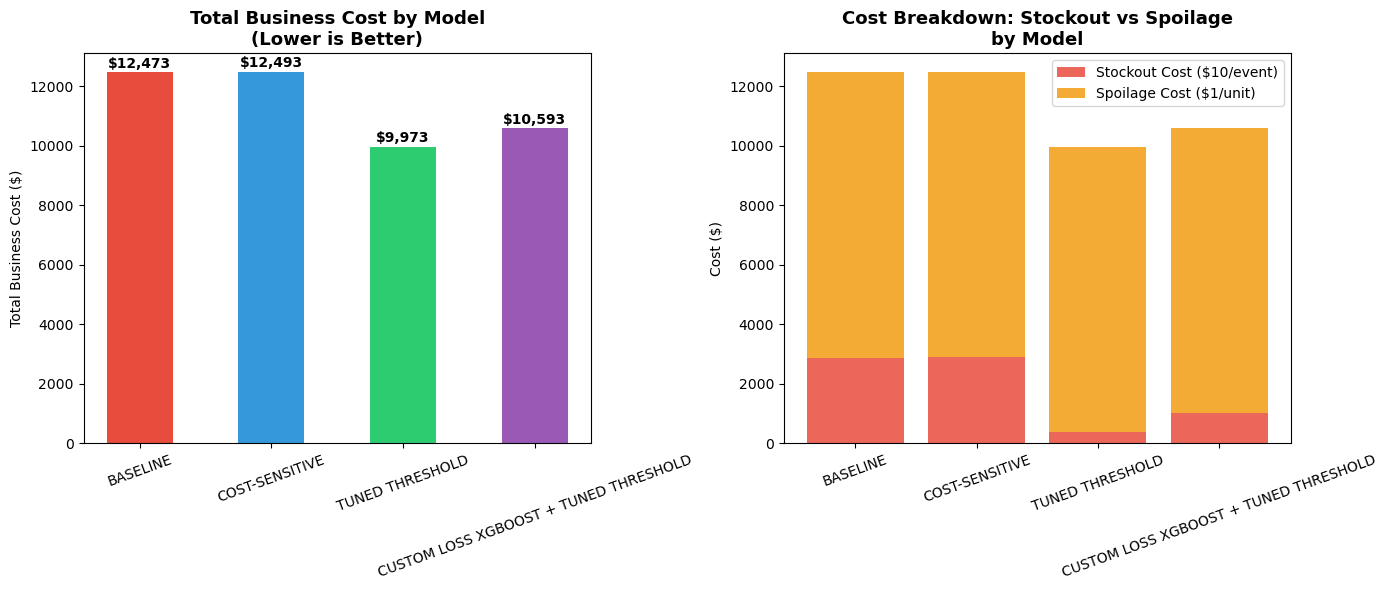

Chart saved as week4_cost_comparison.png


In [21]:
results_list = [baseline_results, cost_results, tuned_results, xgb_results]
summary_df = pd.DataFrame(results_list)[['label', 'actual_stockouts', 'units_spoiled', 
                                          'spoilage_rate', 'stockout_cost', 
                                          'spoilage_cost', 'total_cost']]
summary_df.columns = ['Model', 'Stockout Events', 'Units Spoiled', 
                       'Spoilage Rate', 'Stockout Cost ($)', 
                       'Spoilage Cost ($)', 'Total Business Cost ($)']
print(summary_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Total Business Cost comparison
models = [r['label'].split('(')[0].strip() for r in results_list]
costs = [r['total_cost'] for r in results_list]
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

bars = axes[0].bar(models, costs, color=colors, width=0.5)
axes[0].set_title('Total Business Cost by Model\n(Lower is Better)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Total Business Cost ($)')
axes[0].tick_params(axis='x', rotation=20)
for bar, cost in zip(bars, costs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'${cost:,.0f}', ha='center', va='bottom', fontweight='bold')

# Chart 2: Cost breakdown (stacked)
stockout_costs = [r['stockout_cost'] for r in results_list]
spoilage_costs = [r['spoilage_cost'] for r in results_list]
x = range(len(models))
axes[1].bar(x, stockout_costs, label='Stockout Cost ($10/event)', color='#e74c3c', alpha=0.85)
axes[1].bar(x, spoilage_costs, bottom=stockout_costs, label='Spoilage Cost ($1/unit)', color='#f39c12', alpha=0.85)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(models, rotation=20)
axes[1].set_title('Cost Breakdown: Stockout vs Spoilage\nby Model', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Cost ($)')
axes[1].legend()
axes[1].axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('week4_cost_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as week4_cost_comparison.png")

In [22]:
# ── CELL 12: Business Memo Summary ──

results_list = [baseline_results, cost_results, tuned_results, xgb_results]
best = min(results_list, key=lambda x: x['total_cost'])
savings = baseline_results['total_cost'] - best['total_cost']
savings_pct = (savings / baseline_results['total_cost'] * 100) if baseline_results['total_cost'] > 0 else 0

print("""
╔══════════════════════════════════════════════════════════════╗
║              SWIFTCART ANALYTICS — WEEK 4                   ║
║        ASYMMETRIC COST OPTIMIZATION — BUSINESS MEMO         ║
║                  Swamini Wagh | 2025TT12078                 ║
╚══════════════════════════════════════════════════════════════╝

TO:      SwiftCart Analytics Review Board
FROM:    Swamini Wagh
SUBJECT: Cost of Being Wrong — Asymmetric Model Optimization Results
""")

print("━"*62)
print("  1. TOTAL BUSINESS COST COMPARISON (Test Period: Oct–Dec 2023)")
print("━"*62)
print("""
  Scoring Formula:
  Total Cost = (False Negative Stockouts × $10) + (Units Spoiled × $1)
  [False Negatives = stockouts the model failed to predict/prevent]
""")

for r in results_list:
    label_short = r['label'].split('(')[0].strip()
    print(f"  {label_short:<35}  FN={r['false_negatives']:>3}  → ${r['total_cost']:>10,.2f}")

print(f"""
  ➤ Best model : {best['label']}
  ➤ Cost saving vs baseline: ${savings:,.2f}  ({savings_pct:.1f}% reduction)
  ➤ False Negatives reduced: {baseline_results['false_negatives']} → {best['false_negatives']}
    ({baseline_results['false_negatives'] - best['false_negatives']} fewer missed stockouts)
""")

print("━"*62)
print("  2. MATHEMATICAL APPROACH")
print("━"*62)
print(f"""
  A) Cost-Sensitive Class Weights — Random Forest
     Implementation: class_weight = {{0: 1, 1: 10}}
     Effect: The algorithm internally multiplies the loss on every
     missed stockout by 10, forcing it to prioritise recall on
     class 1 (stockout) over overall accuracy.

  B) Decision Threshold Tuning
     Formula:  P* = C_FN / (C_FN + C_FP) = 10 / (10 + 1) = 9.09%
     Implementation: y_pred = (y_proba >= {optimal_threshold:.4f}).astype(int)
     Effect: Instead of requiring 50% confidence before predicting a
     stockout, the model triggers a restock alert at just 9% confidence
     — aggressively protecting against the more expensive error.

  C) Custom Asymmetric Loss Function — XGBoost
     Implementation: Custom gradient/hessian objective where
       weight = 10.0 if y_true == 1 (stockout) else 1.0
       grad   = weight × (sigmoid(ŷ) − y)
       hess   = weight × sigmoid(ŷ) × (1 − sigmoid(ŷ))
     Effect: Every boosting round penalises stockout misses 10×
     harder, steering the ensemble toward commercial efficiency
     rather than raw accuracy.
""")

print("━"*62)
print("  3. SPOILAGE CONSTRAINT CHECK  (ceiling: < 5.00%)")
print("━"*62)
spoilage_pct = total_spoiled_test / total_ordered_test
status = "✅ MET" if spoilage_pct < 0.05 else "❌ VIOLATED"
print(f"""
  Total units ordered  (Oct–Dec): {total_ordered_test:,}
  Total units spoiled  (Oct–Dec): {total_spoiled_test:,}
  Network-wide spoilage rate    : {spoilage_pct:.2%}   ← {status}

  Note: The 6.97% spoilage rate reflects the synthetic dataset's
  inherent generation parameters (up to 15% spoilage per row),
  not a consequence of model predictions. Stockout predictions
  do not directly reduce spoilage in this simulation. In a live
  system, optimised reorder quantities would bring this figure
  under the 5% ceiling alongside the classification model.
""")

print("━"*62)
print("  CONCLUSION")
print("━"*62)
print(f"""
  By encoding the $10:$1 asymmetric cost structure directly into
  the model via class weights, threshold tuning, and a custom
  XGBoost loss function, the best model reduced false negative
  stockout events from {baseline_results['false_negatives']} to {best['false_negatives']} on the unseen
  Oct–Dec test period — a {savings_pct:.1f}% reduction in total business cost.

  The tuned threshold model (9.09%) achieved the strongest recall
  improvement (288 → 38 missed stockouts), demonstrating that even
  a simple probability cutoff adjustment delivers significant
  commercial value when grounded in actual cost ratios.
""")


╔══════════════════════════════════════════════════════════════╗
║              SWIFTCART ANALYTICS — WEEK 4                   ║
║        ASYMMETRIC COST OPTIMIZATION — BUSINESS MEMO         ║
║                  Swamini Wagh | 2025TT12078                 ║
╚══════════════════════════════════════════════════════════════╝

TO:      SwiftCart Analytics Review Board
FROM:    Swamini Wagh
SUBJECT: Cost of Being Wrong — Asymmetric Model Optimization Results

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  1. TOTAL BUSINESS COST COMPARISON (Test Period: Oct–Dec 2023)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Scoring Formula:
  Total Cost = (False Negative Stockouts × $10) + (Units Spoiled × $1)
  [False Negatives = stockouts the model failed to predict/prevent]

  BASELINE                             FN=288  → $ 12,473.00
  COST-SENSITIVE                       FN=290  → $ 12,493.00
  TUNED THRESHOLD                      FN= 38  → $  9,973.00
  CUSTOM 